## 다층 퍼셉트론(Multilayer perceptron, MLP), 입력층과 출력층 사이에 은닉층을 가진 퍼셉트론

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import Perceptron

### 3.0. 활성화 함수(Activation function)

In [2]:
class ActivationFunctions:
    """입력의 총합을 받아서 출력값을 계산하는 활성화 함수 클래스"""

    def __init__(self, value):
        self.value = value

    def stepfunction(self):
        """계단 함수 메서드
        Logic:
            - 입력 신호의 총합이 0을 넘으면 1을 출력, 0보다 작거나 같으면 0을 출력
        """
        # if self.value > 0.0 : return 1
        # else : return 0
        result = np.asarray(self.value) > 0.0
        # np.asarray로 감싸면 스칼라/배열 모두 처리 가능
        # True or False 반환
        return result.astype(np.int64)
        # 정수형으로 결과값 반환 (numpy 배열을 받기 위함)

    def sigmoidFunction(self):
        """시그모이드 함수 메서드
        Logic:
            - 실수 입력값을 0과 1 사이의 값으로 변환, 전 구간 미분 가능
            - 1 / (1 + e**(-x))
        """
        return 1.0 / (1.0 + np.exp(-self.value))
        # return expit(self.value) # scipy.special.expit

    def hyperbolicTangent(self):
        """쌍곡선 탄젠트 함수 메서드
        Logic:
            - 입력값을 -1과 1 사이의 값으로 변환
            - (e**x - e**(-x)) / (e**x + e**(-x))
        """
        return (np.exp(self.value) - np.exp(-self.value)) / (np.exp(self.value) + np.exp(-self.value))
        # return np.tanh(self.x)
        # return 2.0 / (1.0 + np.exp(-2.0 * self.value)) - 1.0
        
    def RectifiedLinearUnit(self):
        """ReLu 정류된 선형 단위(비선형) 함수 메서드
        Logic:
            - 입력값이 0보다 크면 그 값 출력, 0이하일 경우 0을 출력
            - + / -가 반복되는 신호에서 - 흐름 차단
        """
        return np.maximum(self.value, 0)

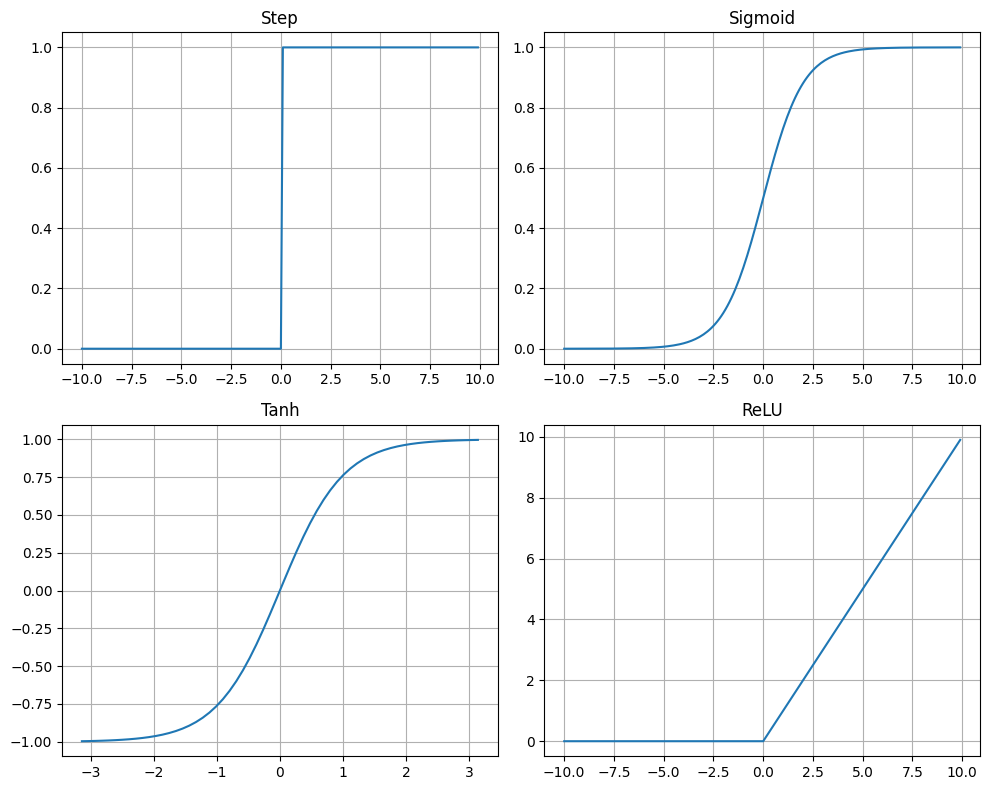

In [3]:
# 활성화 함수 4개를 한 화면에 비교 (2x2 격자)

x = np.arange(-10.0, 10.0, 0.1)
# 입력값 범위: -10 ~ 10, 간격 0.1 (3개 함수 모두 같은 x 사용)
x_prime = np.linspace(-np.pi, np.pi, 60)

acf = ActivationFunctions(value = x)
acfs = ActivationFunctions(value = x_prime)
# 활성화 함수 객체 2개만 만들고, 메서드만 바꿔서 호출

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
# 2행 2열 서브플롯 생성 (figsize: 전체 그림 크기, 가로 10 x 세로 8)

axes[0, 0].plot(x, acf.stepfunction())
axes[0, 0].set_title("Step")
# [0, 0] 계단 함수: 0을 기준으로 0 또는 1 출력

axes[0, 1].plot(x, acf.sigmoidFunction())
axes[0, 1].set_title("Sigmoid")
# [0, 1] 시그모이드: 출력이 0~1 사이로 부드럽게 변함

axes[1, 0].plot(x_prime, acfs.hyperbolicTangent())
axes[1, 0].set_title("Tanh")
# [1, 0] 쌍곡선 탄젠트: 출력이 -1~1 사이, 0 중심 대칭

axes[1, 1].plot(x, acf.RectifiedLinearUnit())
axes[1, 1].set_title("ReLU")
# [1, 1] ReLU: 0 이하는 0, 0 초과는 입력값 그대로 출력

for ax in axes.flat:
    ax.grid(True)
    # 4개 그래프 모두에 격자선 표시

plt.tight_layout()
# 그래프 간 간격 자동 조정 (제목/축 라벨 겹침 방지)
plt.show()

In [ ]:
"""
# 활성화 함수 : 계단 함수 구현
x =  np.arange(-10.0, 10.0, 0.1)
acfs_step = ActivationFunctions(value = x)
y = acfs_step.stepfunction()

plt.plot(x, y)
plt.show()

---

# 활성화 함수 : 시그모이드 함수 구현
x =  np.arange(-10.0, 10.0, 0.1)
acfs_sigmoid = ActivationFunctions(value = x)
y = acfs_sigmoid.sigmoidFunction()

plt.plot(x, y)
plt.show()

---

# 활성화 함수 : 탄젠트 함수 구현
x = np.linspace(-np.pi, np.pi, 60)
acfs_tanh = ActivationFunctions(value = x)
y = acfs_tanh.hyperbolicTangent()

plt.plot(x, y)
plt.show()

---

# 활성화 함수 : ReLu 함수 구현
x =  np.arange(-10.0, 10.0, 0.1)
acfs_relu = ActivationFunctions(value = x)
y = acfs_relu.RectifiedLinearUnit()

plt.plot(x, y)
plt.show()
"""

### 3.1.1. MLP의 순방향 패스 손계산 (Forward pass)


In [5]:
# 가중치(w), 입력(x), 편향(b) 초기값 설정

w_1, w_2, w_3, w_4, w_5,w_6 = 0.1, 0.1, 0.3, 0.4, 0.5, 0.6
#   w_1: x_1 → h_1,  w_3: x_2 → h_1 (h_1으로 들어가는 가중치)
#   w_2: x_1 → h_2,  w_4: x_2 → h_2 (h_2로 들어가는 가중치)
#   w_5: h_1 → y,    w_6: h_2 → y   (출력층으로 들어가는 가중치)

x_1, x_2 = 0, 0
# 입력값 : XOR 게이트의 (0, 0) 케이스 (정답값 0)

b_1, b_2, b_3 = 0.1, 0.2, 0.3
# 편향 : b_1 → h_1 / b_2 → h_2 / b_3 → 출력층

In [6]:
# 은닉층(h_1) 가중합(z_1) + 편향 계산
z_1 = w_1 * x_1 + w_3 * x_2 + b_1
# 행렬 표기 : z = Wx + b

# 은닉층(h_2) 가중합(z_2) + 편향 계산
z_2 = w_2 * x_1 + w_4 * x_2 + b_2

print("은닉층 가중합 z:", z_1, z_2)

은닉층 가중합 z: 0.1 0.2


In [7]:
# 은닉층: 활성화 함수 적용 (a = f(z))
a_1 = ActivationFunctions(value = z_1).sigmoidFunction()
a_2 = ActivationFunctions(value = z_2).sigmoidFunction()

print("은닉층 출력 a:", a_1, a_2)

은닉층 출력 a: 0.52497918747894 0.549833997312478


In [8]:
# 출력층: 가중합 계산
z_y = w_5 * a_1 + w_6 * a_2 + b_3
# 출력층: 활성화 함수 적용 → 최종 출력
a_y = ActivationFunctions(value=z_y).sigmoidFunction()

print("출력층 가중합 z_y:", z_y)
print("최종 출력 a_y:", a_y)
# 정답은 0인데 신경망 출력은 0.7094, 가중치가 아직 학습되지 않은 임의의 값이라 오차가 큼

출력층 가중합 z_y: 0.8923899921269567
최종 출력 a_y: 0.7093831366974158


### 3.1.2. MLP 순방향 패스 알고리즘 - XOR Gate

In [15]:
# 가중치(W), 입력(X), 편향(B) 초기값 설정

# 초기값 random -1 ~ +1
W1 = np.array([[0.10, 0.20], [0.30, 0.40]])
W2 = np.array([[0.50], [0.60]])
B1 = np.array([0.1, 0.2])
B2 = np.array([0.3])

# XOR 게이트 훈련 데이터 (X: 입력 4가지 조합, T: 정답 레이블)
X = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
T = np.array([[0], [1], [1], [0]])

In [16]:
# 각 층의 유닛 개수 (랜덤 초기화 시 가중치 shape을 정하는 데 사용)

# 입력 유닛 개수
inputs = 2
# 은닉 유닛 개수
hiddens = 2
# 출력 유닛 개수
outputs = 1

# 학습률 (eta): 가중치를 한 번에 얼마나 수정할지 결정하는 값
learning_rate = 0.2

In [ ]:
def predict(X):
  """순방향 패스: 입력  → 은닉층 → 출력층 순으로 계산"""
  layer0 = X
  # 입력을 0번째 층에 대입
  
  Z1 = np.dot(layer0, W1) + B1
  # 행렬곱 + 편향 = 은닉층의 가중합
  layer1 = ActivationFunctions(value = Z1).sigmoidFunction()
  # 은닉층 활성화 함수 적용 (시그모이드)

  Z2 = np.dot(layer1, W2) + B2
  # 행렬곱 + 편향 = 출력층의 가중합
  layer2 = ActivationFunctions(value = Z2).sigmoidFunction()
  # 출력층 활성화 함수 적용 (최종 출력)

  return layer0, layer1, layer2

In [ ]:
def test():
  """4개 입력 각각에 대해 (입력, 정답, 신경망 출력)을 출력"""
  for x, y in zip(X, T):
    layer0, layer1, layer2 = predict(x)
    print(x, y, layer2)

In [14]:
test()

[0 0] [0] [0.70938314]
[0 1] [1] [0.72844306]
[1 0] [1] [0.71791234]
[1 1] [0] [0.73598705]


---

### 3.2. 손실함수 [To be continue...]